# Gradient Descent for Logistic Regression

## Goals
Implement the gradient calculations for logistic regression and use them to train w and b.

In [2]:
import copy,math
import numpy as np
import matplotlib.pyplot as plt

In [4]:
#sigmoid_function
def sigmoid(z):
    g = 1 / (1 + np.exp(-z))
    return np.clip(g,1e-10,1 - 1e-10)

In [5]:
#cost_fucntion
def compute_cost_logistic(x,y,w,b):
    m = x.shape[0]
    cost = 0.0
    for i in range(m):
        z_i = np.dot(x[i],w)+b
        f_wb_i = sigmoid(z_i)
        cost+= -y[i]*np.log(f_wb_i) - (1-y[i])*np.log(1-f_wb_i)
    cost = cost/m
    return cost

### Data set
Let's start with the same two feature data set used in the decision boundary lab.

In [6]:
X_train = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_train = np.array([0, 0, 0, 1, 1, 1])

### Plotting the data
The data points with label y=1 are shown as red crosses, and the data points with label y=0 are shown as blue circles.

In [7]:
def plot_data(X,y,ax):
    y_flat = y.flatten() if y.ndim>1 else y
    pos = y == 1
    neg = y == 0
    ax.scatter(X[pos,0],X[pos,1],marker='x',c='r',label="y=1")
    ax.scatter(X[neg,0],X[neg,1],marker='o',edgecolors="blue",facecolors="none",label="y=0")
    ax.legend()

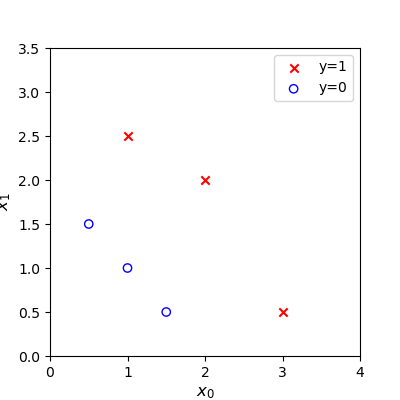

In [8]:
fig,ax = plt.subplots(1,1,figsize=(4,4))
plot_data(X_train, y_train, ax)

ax.axis([0, 4, 0, 3.5])
ax.set_ylabel('$x_1$', fontsize=12)
ax.set_xlabel('$x_0$', fontsize=12)
plt.savefig("w3_lab06_data_scatter.png")
plt.close()
from IPython.display import Image
Image("w3_lab06_data_scatter.png")

## Logistic Gradient Descent
Recall the gradient descent update rule updates w and b using the partial derivatives of the cost function, where the gradient for logistic regression has the same form as linear regression but uses the sigmoid prediction instead of a plain linear one.

### compute_gradient_logistic
Calculates dj_dw and dj_db for logistic regression, same structure as the linear regression version but using sigmoid instead of a plain linear prediction.

In [9]:
def compute_gradient_logistic(X, y, w, b): 
    m,n = X.shape
    dj_dw = np.zeros((n,))
    dj_db = 0.

    for i in range(m):
        f_wb_i = sigmoid(np.dot(X[i],w) + b)
        err_i  = f_wb_i - y[i]
        for j in range(n):
            dj_dw[j] = dj_dw[j] + err_i * X[i,j]
        dj_db = dj_db + err_i
    dj_dw = dj_dw/m
    dj_db = dj_db/m
        
    return dj_db, dj_dw

### Verifying compute_gradient_logistic
Check the gradient function against known expected output using a fixed set of test values.

In [10]:
X_tmp = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_tmp = np.array([0, 0, 0, 1, 1, 1])
w_tmp = np.array([2.,3.])
b_tmp = 1.
dj_db_tmp, dj_dw_tmp = compute_gradient_logistic(X_tmp, y_tmp, w_tmp, b_tmp)
print(f"dj_db: {dj_db_tmp}" )
print(f"dj_dw: {dj_dw_tmp.tolist()}" )

dj_db: 0.49861806546328574
dj_dw: [0.498333393278696, 0.49883942983996693]


### gradient_descent
Runs the gradient descent loop, repeatedly calling compute_gradient_logistic to update w and b, and records the cost at each iteration for later inspection.

In [11]:
def gradient_descent(X, y, w_in, b_in, alpha, num_iters): 
    J_history = []
    w = copy.deepcopy(w_in)
    b = b_in
    
    for i in range(num_iters):
        dj_db, dj_dw = compute_gradient_logistic(X, y, w, b)   

        w = w - alpha * dj_dw               
        b = b - alpha * dj_db               
      
        if i<100000:
            J_history.append( compute_cost_logistic(X, y, w, b) )

        if i% math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]}   ")
        
    return w, b, J_history

### Running gradient descent
Run gradient descent on the two feature data set and inspect the resulting parameters.

In [12]:
w_tmp  = np.zeros_like(X_train[0])  #create the array with same dimensions like X_train
b_tmp  = 0.
alph = 0.1
iters = 10000

w_out, b_out, _ = gradient_descent(X_train, y_train, w_tmp, b_tmp, alph, iters) 
print(f"\nupdated parameters: w:{w_out}, b:{b_out}")

Iteration    0: Cost 0.684610468560574   
Iteration 1000: Cost 0.1590977666870457   
Iteration 2000: Cost 0.08460064176930078   
Iteration 3000: Cost 0.05705327279402531   
Iteration 4000: Cost 0.04290759421682   
Iteration 5000: Cost 0.03433847729884557   
Iteration 6000: Cost 0.02860379802212006   
Iteration 7000: Cost 0.02450156960879306   
Iteration 8000: Cost 0.02142370332569295   
Iteration 9000: Cost 0.019030137124109114   

updated parameters: w:[5.28123029 5.07815608], b:-14.222409982019837


### Plotting the results
Plot the trained decision boundary along with the original data points.

In [14]:
def plt_prob(ax, w, b):
    x0 = np.linspace(0, 4, 100)
    x1 = np.linspace(0, 3.5, 100)
    X0, X1 = np.meshgrid(x0, x1)  #to create two matrix
    Z = sigmoid(w[0]*X0 + w[1]*X1 + b)
    ax.contourf(X0, X1, Z, levels=20, cmap='Blues', alpha=0.4)

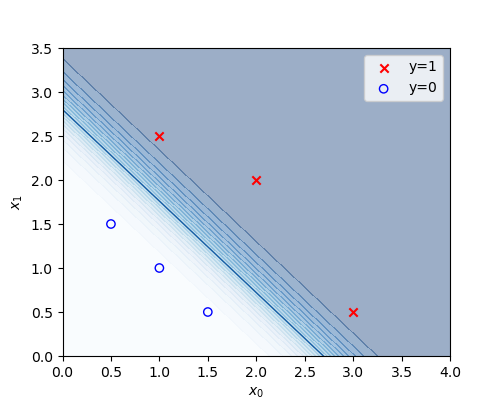

In [15]:
fig,ax = plt.subplots(1,1,figsize=(5,4))
plt_prob(ax, w_out, b_out)

ax.set_ylabel(r'$x_1$')
ax.set_xlabel(r'$x_0$')   
ax.axis([0, 4, 0, 3.5])
plot_data(X_train,y_train,ax)

x0 = -b_out/w_out[0]
x1 = -b_out/w_out[1]
ax.plot([0,x0],[x1,0], c='#185FA5', lw=1)

plt.savefig("w3_lab06_decision_boundary.png")
plt.close()
from IPython.display import Image
Image("w3_lab06_decision_boundary.png")

### Another data set
With just two parameters, w and b, it is possible to visualize the cost function to get a better idea of what gradient descent is doing.

In [17]:
x_train = np.array([0., 1, 2, 3, 4, 5])
y_train = np.array([0,  0, 0, 1, 1, 1])

### Plotting the data
The data points with label y=1 are shown as red crosses, and the data points with label y=0 are shown as blue circles.

In [19]:
def plt_tumor_data(x, y, ax):
    pos = y == 1
    neg = y == 0
    ax.scatter(x[pos], np.zeros_like(x[pos]) + 1, marker='x', c='red', label='y=1')
    ax.scatter(x[neg], np.zeros_like(x[neg]), marker='o', edgecolors='blue', facecolors='none', label='y=0')
    ax.set_ylim(-0.1, 1.1)
    ax.legend()

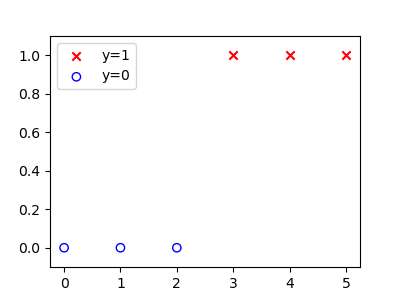

In [20]:
fig,ax = plt.subplots(1,1,figsize=(4,3))
plt_tumor_data(x_train, y_train, ax)
plt.savefig("w3_lab06_tumor_data.png")
plt.close()
from IPython.display import Image
Image("w3_lab06_tumor_data.png")

### Visualizing the cost function
Plot how the cost changes across different values of w and b, to build intuition for what gradient descent is minimizing.

In [ ]:
w_range = np.linspace(-1, 7, 50)
b_range = np.linspace(-14, 1, 50)
W, B = np.meshgrid(w_range, b_range)

cost_vals = np.zeros_like(W)
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        cost_vals[i,j] = compute_cost_logistic(x_train.reshape(-1,1), y_train, np.array([W[i,j]]), B[i,j])

fig, ax = plt.subplots(1,1,figsize=(5,4))
cp = ax.contour(W, B, cost_vals, levels=20, cmap='viridis')
ax.plot(w_out[0], b_out, 'r*', markersize=15, label='gradient descent result')
ax.set_xlabel('w')
ax.set_ylabel('b')
ax.legend()
plt.savefig("w3_lab06_cost_surface.png")
plt.close()
from IPython.display import Image
Image("w3_lab06_cost_surface.png")